In [65]:
'''
IMPORTING LIBRARIES
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [66]:
retail = pd.read_excel('/content/Online+Retail.xlsx')

retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [67]:
retail_df = retail.copy()

In [68]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [69]:
retail_df.describe().round(2)

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [70]:
retail_df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [71]:
retail_df.duplicated().sum()

np.int64(5268)

In [72]:
retail_df = retail_df.drop_duplicates()

In [73]:
retail_df = retail_df.dropna()

In [74]:
retail_df.shape

(401604, 8)

In [75]:
retail_df['Description']

,Description
0,WHITE HANGING HEART T-LIGHT HOLDER
1,WHITE METAL LANTERN
2,CREAM CUPID HEARTS COAT HANGER
3,KNITTED UNION FLAG HOT WATER BOTTLE
4,RED WOOLLY HOTTIE WHITE HEART.
...,...
541904,PACK OF 20 SPACEBOY NAPKINS
541905,CHILDREN'S APRON DOLLY GIRL
541906,CHILDRENS CUTLERY DOLLY GIRL
541907,CHILDRENS CUTLERY CIRCUS PARADE


In [76]:
retail_df.groupby('Description').agg({'Quantity':'sum'}).sort_values('Quantity',ascending=False)

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53119
JUMBO BAG RED RETROSPOT,44963
ASSORTED COLOUR BIRD ORNAMENT,35215
WHITE HANGING HEART T-LIGHT HOLDER,34128
PACK OF 72 RETROSPOT CAKE CASES,33386
...,...
PINK POODLE HANGING DECORATION,-12
CRUK Commission,-16
ASSORTED TUTTI FRUTTI ROUND BOX,-24


In [77]:
retail_df['InvoiceNo'].str.contains('C').sum()

8872

In [78]:
retail_df = retail_df[~retail_df['InvoiceNo'].str.contains('C',na=False)]

In [79]:
retail_df['TotalPrice'] = retail_df['Quantity']*retail_df['UnitPrice']

In [80]:
retail_df.head(50)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08


In [81]:
rfm = retail_df.groupby('CustomerID').agg({'InvoiceDate':'max',
                                           'InvoiceNo':'count',
                                           'TotalPrice':'sum'})

In [82]:
rfm

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,2011-01-18 10:01:00,1,77183.60
12347.0,2011-12-07 15:52:00,182,4310.00
12348.0,2011-09-25 13:13:00,31,1797.24
12349.0,2011-11-21 09:51:00,73,1757.55
12350.0,2011-02-02 16:01:00,17,334.40
...,...,...,...
18280.0,2011-03-07 09:52:00,10,180.60
18281.0,2011-06-12 10:53:00,7,80.82
18282.0,2011-12-02 11:43:00,12,178.05


In [83]:
rfm.columns = ['LastPurchaseDate','Frequency','Monetary']

In [84]:
rfm

,LastPurchaseDate,Frequency,Monetary
CustomerID,,,
12346.0,2011-01-18 10:01:00,1,77183.60
12347.0,2011-12-07 15:52:00,182,4310.00
12348.0,2011-09-25 13:13:00,31,1797.24
12349.0,2011-11-21 09:51:00,73,1757.55
12350.0,2011-02-02 16:01:00,17,334.40
...,...,...,...
18280.0,2011-03-07 09:52:00,10,180.60
18281.0,2011-06-12 10:53:00,7,80.82
18282.0,2011-12-02 11:43:00,12,178.05


In [85]:
rfm = rfm[rfm['Monetary'] > 0]

In [86]:
rfm

,LastPurchaseDate,Frequency,Monetary
CustomerID,,,
12346.0,2011-01-18 10:01:00,1,77183.60
12347.0,2011-12-07 15:52:00,182,4310.00
12348.0,2011-09-25 13:13:00,31,1797.24
12349.0,2011-11-21 09:51:00,73,1757.55
12350.0,2011-02-02 16:01:00,17,334.40
...,...,...,...
18280.0,2011-03-07 09:52:00,10,180.60
18281.0,2011-06-12 10:53:00,7,80.82
18282.0,2011-12-02 11:43:00,12,178.05


In [87]:
rfm.describe().T

,count,mean,min,25%,50%,75%,max,std
LastPurchaseDate,4338,2011-09-08 11:38:59.045643008,2010-12-01 09:53:00,2011-07-20 19:18:00,2011-10-20 10:40:30,2011-11-22 11:05:45,2011-12-09 12:50:00,NaN
Frequency,4338.0,90.532734,1.0,17.0,41.0,98.0,7676.0,225.537229
Monetary,4338.0,2048.688081,3.75,306.4825,668.57,1660.5975,280206.02,8985.23022


In [88]:
rfm['LastPurchaseDate_score'] = pd.qcut(rfm['LastPurchaseDate'].rank(method='first'),5,labels=[5,4,3,2,1])

In [89]:
rfm['Frequency_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])

In [90]:
rfm['Monetary_score'] = pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])

In [91]:
rfm

,LastPurchaseDate,Frequency,Monetary,LastPurchaseDate_score,Frequency_score,Monetary_score
CustomerID,,,,,,
12346.0,2011-01-18 10:01:00,1,77183.60,5,1,5
12347.0,2011-12-07 15:52:00,182,4310.00,1,5,5
12348.0,2011-09-25 13:13:00,31,1797.24,4,3,4
12349.0,2011-11-21 09:51:00,73,1757.55,2,4,4
12350.0,2011-02-02 16:01:00,17,334.40,5,2,2
...,...,...,...,...,...,...
18280.0,2011-03-07 09:52:00,10,180.60,5,1,1
18281.0,2011-06-12 10:53:00,7,80.82,5,1,1
18282.0,2011-12-02 11:43:00,12,178.05,1,1,1


In [92]:
rfm['RFM_SCORE'] = (rfm['LastPurchaseDate_score'].astype(str) +
                    rfm['Frequency_score'].astype(str))

In [93]:
rfm

,LastPurchaseDate,Frequency,Monetary,LastPurchaseDate_score,Frequency_score,Monetary_score,RFM_SCORE
CustomerID,,,,,,,
12346.0,2011-01-18 10:01:00,1,77183.60,5,1,5,51
12347.0,2011-12-07 15:52:00,182,4310.00,1,5,5,15
12348.0,2011-09-25 13:13:00,31,1797.24,4,3,4,43
12349.0,2011-11-21 09:51:00,73,1757.55,2,4,4,24
12350.0,2011-02-02 16:01:00,17,334.40,5,2,2,52
...,...,...,...,...,...,...,...
18280.0,2011-03-07 09:52:00,10,180.60,5,1,1,51
18281.0,2011-06-12 10:53:00,7,80.82,5,1,1,51
18282.0,2011-12-02 11:43:00,12,178.05,1,1,1,11


In [94]:
rfm[rfm['RFM_SCORE'] == '55']

,LastPurchaseDate,Frequency,Monetary,LastPurchaseDate_score,Frequency_score,Monetary_score,RFM_SCORE
CustomerID,,,,,,,
12501.0,2011-01-07 12:28:00,149,2169.390,5,5,5,55
13093.0,2011-03-09 12:14:00,159,7832.470,5,5,5,55
13952.0,2011-05-06 09:00:00,137,3251.071,5,5,5,55
14081.0,2011-02-10 16:17:00,150,921.620,5,5,3,55
14465.0,2011-04-07 12:38:00,123,1038.440,5,5,4,55
14573.0,2011-06-13 11:15:00,227,1639.820,5,5,4,55
14669.0,2011-04-12 11:43:00,166,1259.240,5,5,4,55
14670.0,2011-03-04 14:13:00,123,392.860,5,5,2,55
15235.0,2011-05-06 09:44:00,143,2247.510,5,5,5,55


In [95]:
'''
CUSTOMER SEGMENTATION BASED ON RFM SCORES
'''
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Loose',

    r'3[1-2]': 'About To Sleep',
    r'3[3-4]': 'Need Attention',
    r'35': 'Loyal Customers',

    r'41': 'Promising',
    r'4[2-3]': 'Potential Loyalists',
    r'4[4-5]': 'Loyal Customers',

    r'5[1-2]': 'New Customers',
    r'53': 'Potential Loyalists',
    r'54': 'Loyal Customers',
    r'55': 'Champions'
}
rfm['Segment'] = rfm['RFM_SCORE'].replace(seg_map, regex=True)
rfm

,LastPurchaseDate,Frequency,Monetary,LastPurchaseDate_score,Frequency_score,Monetary_score,RFM_SCORE,Segment
CustomerID,,,,,,,,
12346.0,2011-01-18 10:01:00,1,77183.60,5,1,5,51,New Customers
12347.0,2011-12-07 15:52:00,182,4310.00,1,5,5,15,Can't Loose
12348.0,2011-09-25 13:13:00,31,1797.24,4,3,4,43,Potential Loyalists
12349.0,2011-11-21 09:51:00,73,1757.55,2,4,4,24,At Risk
12350.0,2011-02-02 16:01:00,17,334.40,5,2,2,52,New Customers
...,...,...,...,...,...,...,...,...
18280.0,2011-03-07 09:52:00,10,180.60,5,1,1,51,New Customers
18281.0,2011-06-12 10:53:00,7,80.82,5,1,1,51,New Customers
18282.0,2011-12-02 11:43:00,12,178.05,1,1,1,11,Hibernating


In [96]:
rfm[["LastPurchaseDate", "Frequency", "Monetary", "Segment"]].groupby("Segment").agg(["mean", "count", "max"])

LastPurchaseDate                            \
                                             mean count                 max   
Segment                                                                       
About To Sleep      2011-10-18 12:27:25.552050432   317 2011-11-07 11:09:00   
At Risk             2011-11-24 14:14:20.270270208   740 2011-12-09 12:50:00   
Can't Loose         2011-11-28 05:49:37.934272256   639 2011-12-09 12:49:00   
Champions           2011-03-26 18:21:06.315789568    19 2011-06-13 11:15:00   
Hibernating         2011-11-23 02:33:49.382022400   356 2011-12-09 10:45:00   
Loyal Customers     2011-08-19 18:10:18.997722112   439 2011-11-07 11:37:00   
Need Attention      2011-10-20 06:51:42.475247616   404 2011-11-07 11:33:00   
New Customers       2011-03-13 05:57:23.830455296   637 2011-06-13 14:59:00   
Potential Loyalists 2011-07-11 16:33:02.400000000   575 2011-09-29 10:52:00   
Promising           2011-08-14 03:29:46.698113280   212 2011-09-29 10:50:00   

                      Frequency                 Monetary                   
                           mean count   max         mean count        max  
Segment                                                                    
About To Sleep        15.643533   317    29   447.288044   317    7330.80  
At Risk               68.239189   740   120  1721.598108   740   58510.48  
Can't Loose          336.111111   639  7676  7442.861894   639  280206.02  
Champions            158.210526    19   297  2145.418474    19    7832.47  
Hibernating           15.117978   356    29  1032.158343   356  168472.50  
Loyal Customers      136.660592   439   656  2281.784556   439   80850.84  
Need Attention        62.400990   404   120  1128.674012   404   11581.80  
New Customers         12.819466   637    29   558.438195   637   77183.60  
Potential Loyalists   33.386087   575    57   713.210960   575    7829.89  
Promising              7.287736   212    14   394.937547   212    4055.72

### Visualization of RFM Segments

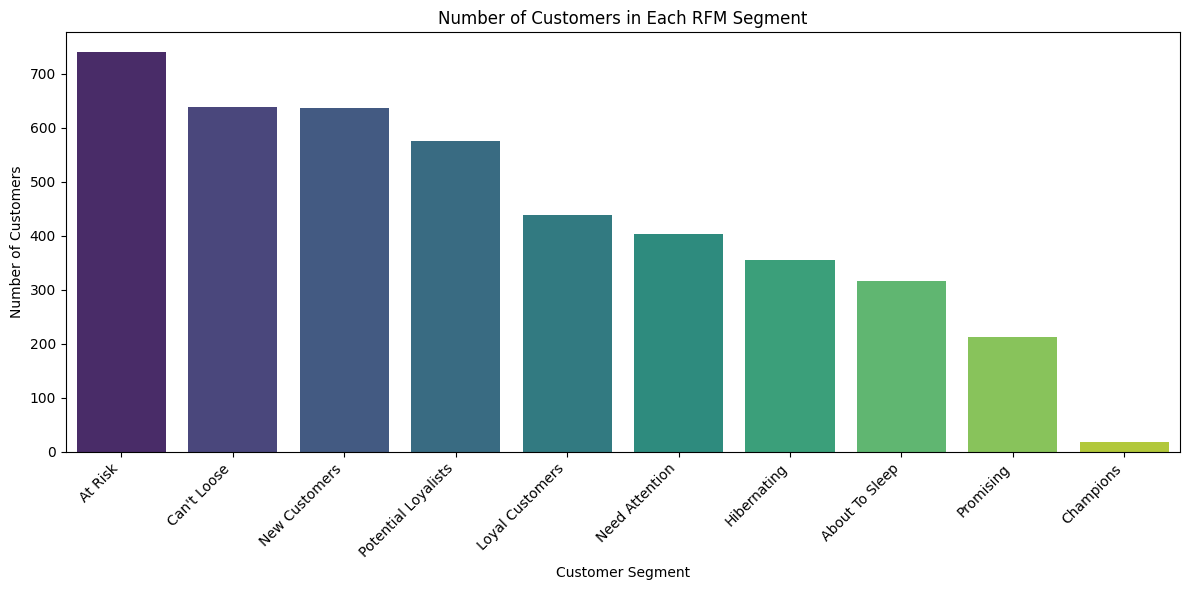

In [97]:
plt.figure(figsize=(12, 6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Number of Customers in Each RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

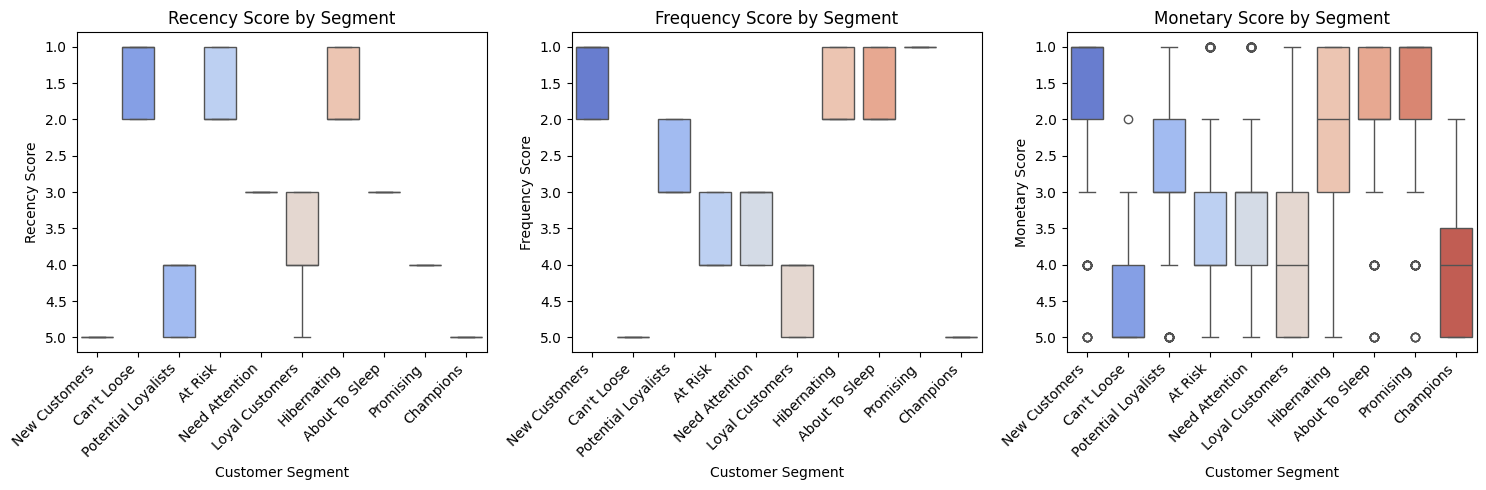

In [98]:
# Box plot for Recency (LastPurchaseDate_score) across segments
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=rfm, x='Segment', y='LastPurchaseDate_score', palette='coolwarm')
plt.title('Recency Score by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Recency Score')
plt.xticks(rotation=45, ha='right')

# Box plot for Frequency (Frequency_score) across segments
plt.subplot(1, 3, 2)
sns.boxplot(data=rfm, x='Segment', y='Frequency_score', palette='coolwarm')
plt.title('Frequency Score by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Frequency Score')
plt.xticks(rotation=45, ha='right')

# Box plot for Monetary (Monetary_score) across segments
plt.subplot(1, 3, 3)
sns.boxplot(data=rfm, x='Segment', y='Monetary_score', palette='coolwarm')
plt.title('Monetary Score by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Monetary Score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Grouped Bar Chart of Mean RFM Scores by Segment

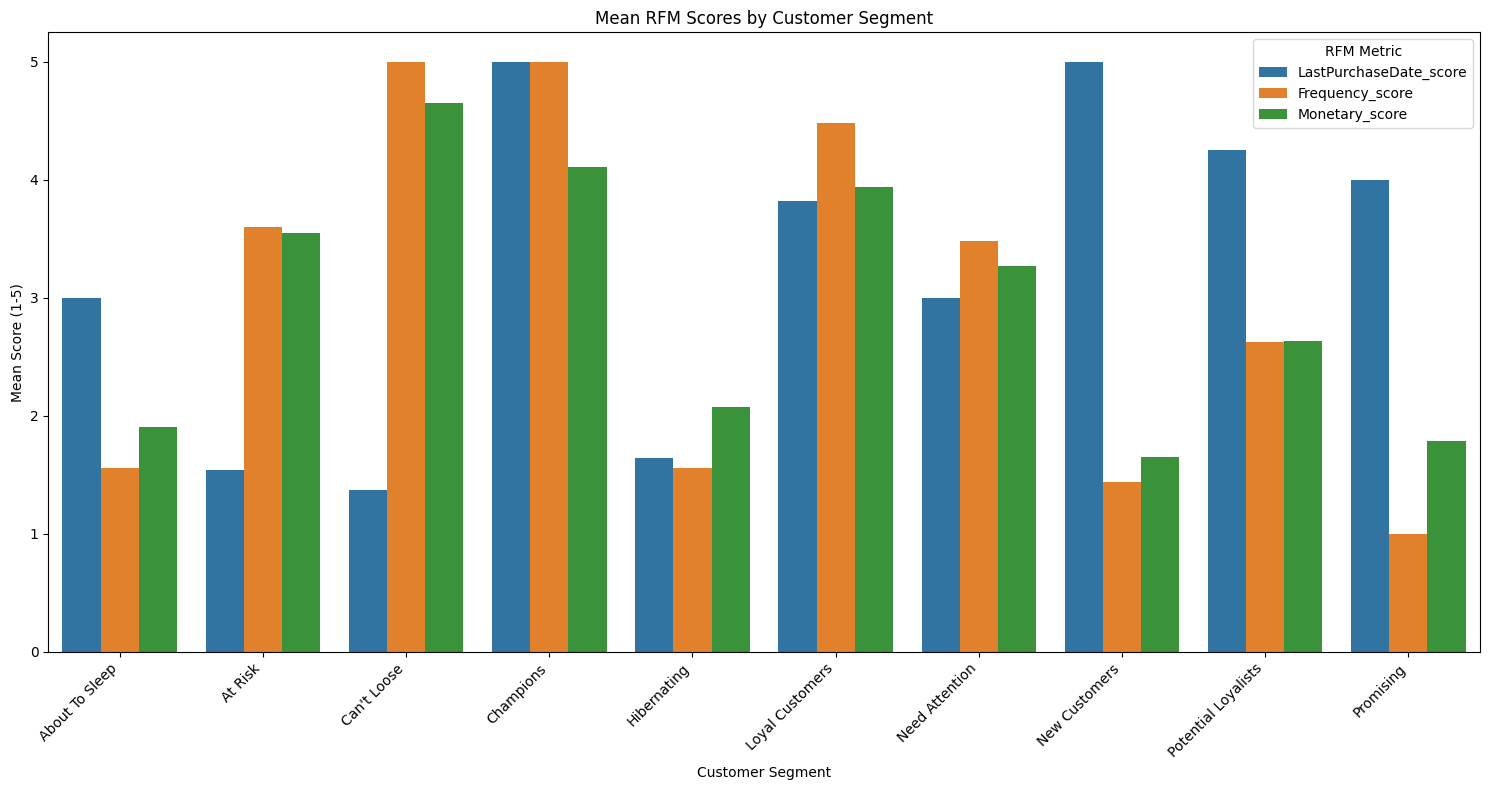

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the segment_rfm_means DataFrame to a long format for easier plotting with seaborn
segment_rfm_means_melted = segment_rfm_means.melt(id_vars='Segment', var_name='RFM_Metric', value_name='Mean_Score')

plt.figure(figsize=(15, 8))
sns.barplot(x='Segment', y='Mean_Score', hue='RFM_Metric', data=segment_rfm_means_melted, palette='tab10')
plt.title('Mean RFM Scores by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Mean Score (1-5)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='RFM Metric')
plt.tight_layout()
plt.show()